In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdat
import cv2
import glob
import sys
sys.path.append("../libraries/")
import sun_position_calc as sun
import pandas as pd
import datetime as dt
import scipy.stats as stats

from concurrent.futures import ThreadPoolExecutor

In [2]:
# get image filepaths, timestamps, and true sun positions

year = "2026"
month = "05"
day = "26"

camera = "ref"  #(main->DIY, ref-> commercial)

filepath_collector = []

timestamp_collector = []
sun_theta_collector = []
sun_phi_collector = []

if camera=="main":
    
    cur_dir = "/projekt1/ag_maahn/data_obs/lim/allsky1/images/{0}/{1}/{2}/".format(year, month, day)
    filepath_collector = glob.glob(cur_dir + "**/*.png", recursive=True)
    filepath_collector.sort() 

    for path in filepath_collector:
        
        cur_timestamp = dt.datetime.strptime(path[-19:-4], "%Y%m%d_%H%M%S")    
        sun_pos_raw = sun.calc_sun_pos(51.333276, 12.388643, cur_timestamp)

        timestamp_collector.append(cur_timestamp)
        
        sun_theta_collector.append(sun_pos_raw[0])
        sun_phi_collector.append(sun_pos_raw[1])
    
elif camera=="ref":
    cur_dir = "/projekt1/ag_maahn/data_obs/lim/allsky_ref/asi_16327/{0}{1}{2}/".format(year, month, day)
    filepath_collector = glob.glob(cur_dir + "**/*.jpg", recursive=True)
    filepath_collector.sort()

    for path in filepath_collector:
        
        cur_timestamp = dt.datetime.strptime(path[-21:-7], "%Y%m%d%H%M%S")
        sun_pos_raw = sun.calc_sun_pos(51.333276, 12.388643, cur_timestamp)

        timestamp_collector.append(cur_timestamp)      

        sun_theta_collector.append(sun_pos_raw[0])
        sun_phi_collector.append(sun_pos_raw[1])
    
else:
    print("Unknown camera identifier (select: main, ref)")

In [3]:
# detect sun in image
actual_radius_collector = []
actual_angle_collector = []

x_collector = []
y_collector = []

counter = 0

if camera == "main":
    img_half = 1520
    max_theta = 95
elif camera == "ref":
    img_half = 960
    max_theta = 90


def calc_values(filepath, true_theta):
    
    if true_theta > 80:
        return np.nan, np.nan, np.nan, np.nan, np.nan

    if camera == "main":
    
        img_raw = cv2.imread(filepath, -1)
        img_gray = cv2.demosaicing(img_raw, cv2.COLOR_BAYER_BGGR2GRAY)
        
        img_mask = np.zeros_like(img_gray, dtype="uint8")
        img_mask = np.where(img_gray>4050, 1, 0)
        
    elif camera == "ref":

        img_raw = cv2.imread(filepath, -1)

        mask = np.zeros_like(img_raw)
        mask = cv2.circle(mask,(960,960), 960, (255,255,255), -1)

        img_rgb = cv2.bitwise_and(img_raw, mask)
        
        img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2GRAY)
        img_mask = np.zeros_like(img_gray, dtype="uint8")
        img_mask = np.where(img_gray>245, 1, 0)

    if np.sum(img_mask) < 100:
        return np.nan, np.nan, np.nan, np.nan, np.nan
    
    cntrs,_ = cv2.findContours(img_mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    
    cmax = max(cntrs, key = cv2.contourArea)
    M = cv2.moments(cmax)
    cX = int(M["m10"] / M["m00"])
    cY = int(M["m01"] / M["m00"])

    xrel = cX - img_half
    yrel = cY - img_half
    
    calculated_r = np.sqrt(xrel**2 + yrel**2)
    calculated_angle = np.rad2deg(np.atan2(-yrel, xrel)) - 90
    if (yrel>0) or (yrel<=0 and xrel>=0):
        calculated_angle += 360

    return calculated_r, calculated_angle, cX, cY, img_gray

counter=0
images_n = len(filepath_collector)
start_time = dt.datetime.now()

background_image = -1

with ThreadPoolExecutor(max_workers=16) as executor:
    for res in executor.map(calc_values, filepath_collector, sun_theta_collector):

        counter += 1

        if np.isfinite(res[0]):
            background_image = res[4]
        
        progress_percent = np.round(counter/images_n * 100, 3)
        runtime_sec = (dt.datetime.now() - start_time).seconds
        
        print("Running {3:02d}:{4:02d} - {0} of {1} images processed ({2:.3f} %)".format(counter, images_n, progress_percent, 
                                                                                 runtime_sec // 60, runtime_sec % 60), end="\r")

        actual_radius_collector.append(res[0])
        actual_angle_collector.append(res[1])
        x_collector.append(res[2])
        y_collector.append(res[3])

print("")
print("Done")

Running 00:06 - 2050 of 2050 images processed (100.000 %)
Done


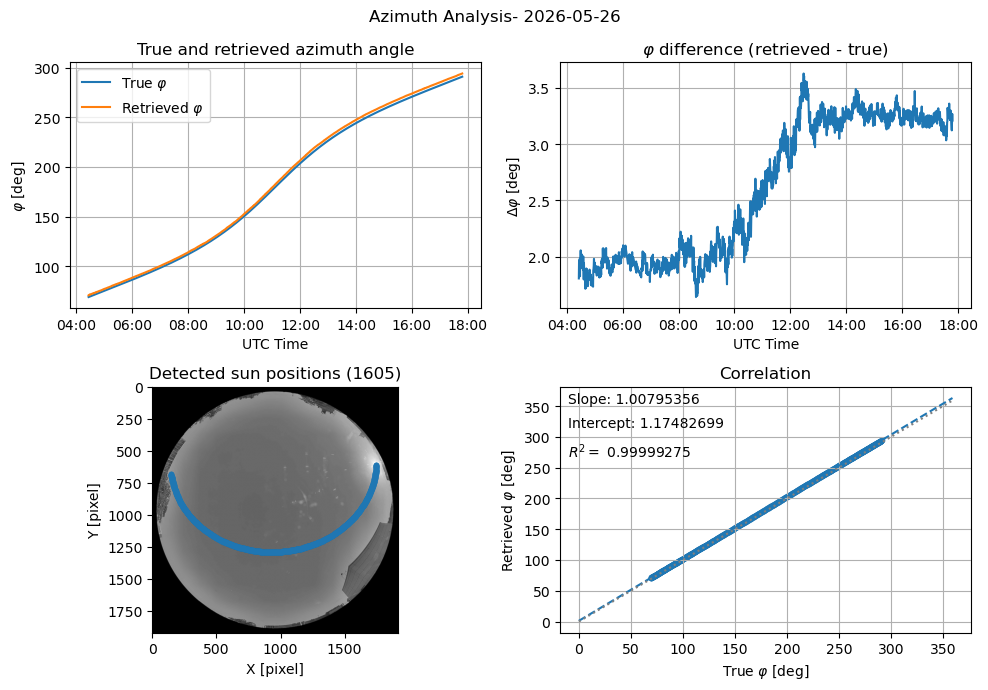

In [5]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10,7))

fig.suptitle("Azimuth Analysis- {0}-{1}-{2}".format(year, month, day))

new_true_phi = np.where(np.isnan(actual_angle_collector), np.nan, sun_phi_collector)

ax[0,0].plot(timestamp_collector, new_true_phi, label=r'True $\varphi$')
ax[0,0].plot(timestamp_collector, actual_angle_collector, label=r'Retrieved $\varphi$')
ax[0,0].set_title("True and retrieved azimuth angle")
ax[0,0].set_xlabel("UTC Time")
ax[0,0].xaxis.set_major_formatter(mdat.DateFormatter("%H:%M"))
ax[0,0].set_ylabel(r'$\varphi$ [deg]')
ax[0,0].legend()
ax[0,0].grid()

ax[0,1].plot(np.array(timestamp_collector), np.array(actual_angle_collector)-np.array(sun_phi_collector))
ax[0,1].set_title(r'$\varphi$ difference (retrieved - true)')
ax[0,1].set_xlabel("UTC Time")
ax[0,1].xaxis.set_major_formatter(mdat.DateFormatter("%H:%M"))
ax[0,1].set_ylabel(r'$\Delta\varphi$ [deg]')
ax[0,1].grid()

ax[1,0].imshow(background_image, cmap="gray")
ax[1,0].scatter(x_collector, y_collector, marker='.', alpha=0.7)
ax[1,0].set_title("Detected sun positions ({0})".format((np.isfinite(x_collector)).sum()))
ax[1,0].set_xlabel("X [pixel]")
ax[1,0].set_ylabel("Y [pixel]")
ax[1,0].set_xlim(0, img_half*2)
ax[1,0].set_ylim(0, img_half*2)
ax[1,0].invert_yaxis()

ax[1,1].scatter(sun_phi_collector, actual_angle_collector, marker=".", alpha=0.7)
ax[1,1].set_title("Correlation")
ax[1,1].set_xlabel(r'True $\varphi$ [deg]')
ax[1,1].set_ylabel(r'Retrieved $\varphi$ [deg]')
ax[1,1].grid()

lreg = stats.linregress(sun_phi_collector, actual_angle_collector, nan_policy = "omit")
reg_gen_x = np.arange(0, 360, 1)
reg_gen_y = lreg.slope * reg_gen_x + lreg.intercept
ax[1,1].plot(reg_gen_x, reg_gen_y, linestyle = "--")
ax[1,1].plot(reg_gen_x, reg_gen_x, linestyle = ":", color="gray")
ax[1,1].text(0.02, 0.98, "Slope: {0}".format(np.round(lreg.slope, 8)), ha='left', va='top', transform=ax[1,1].transAxes)
ax[1,1].text(0.02, 0.88, "Intercept: {0}".format(np.round(lreg.intercept, 8)), ha='left', va='top', transform=ax[1,1].transAxes)
ax[1,1].text(0.02, 0.78, r'$R^2 =$ {0}'.format(np.round(lreg.rvalue**2, 8)), ha='left', va='top', transform=ax[1,1].transAxes)

#fig.autofmt_xdate()
fig.tight_layout()

fig.savefig("{0}_phi_{1}{2}{3}.png".format(camera, year, month, day))

 "rectilinear" selected
 "sterographic" selected
 "equidistant" selected
 "equisolid" selected
 "orthographic" selected


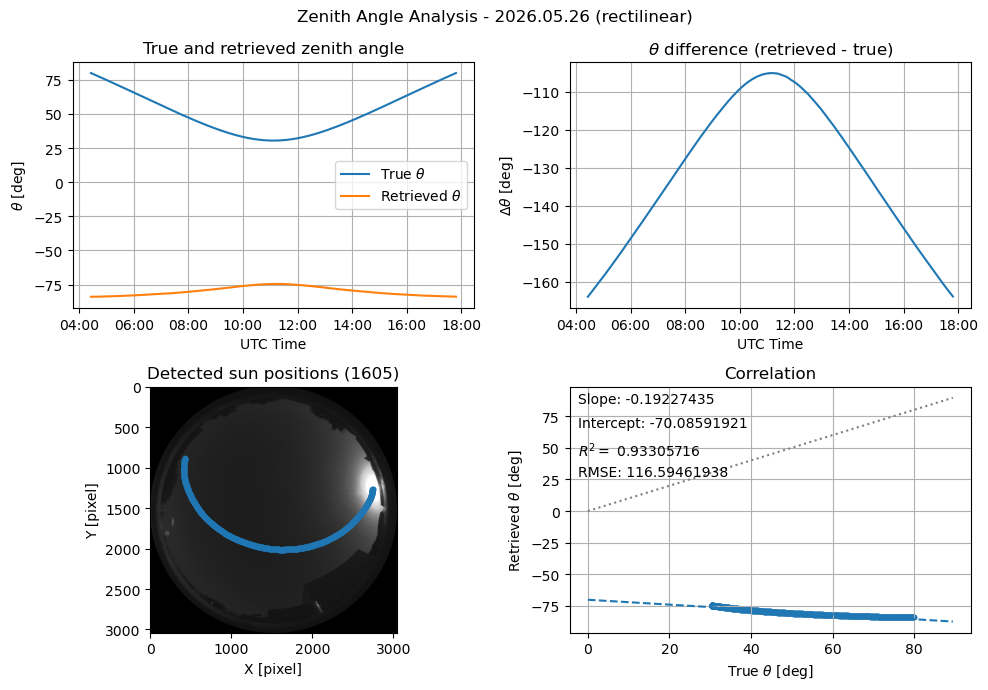

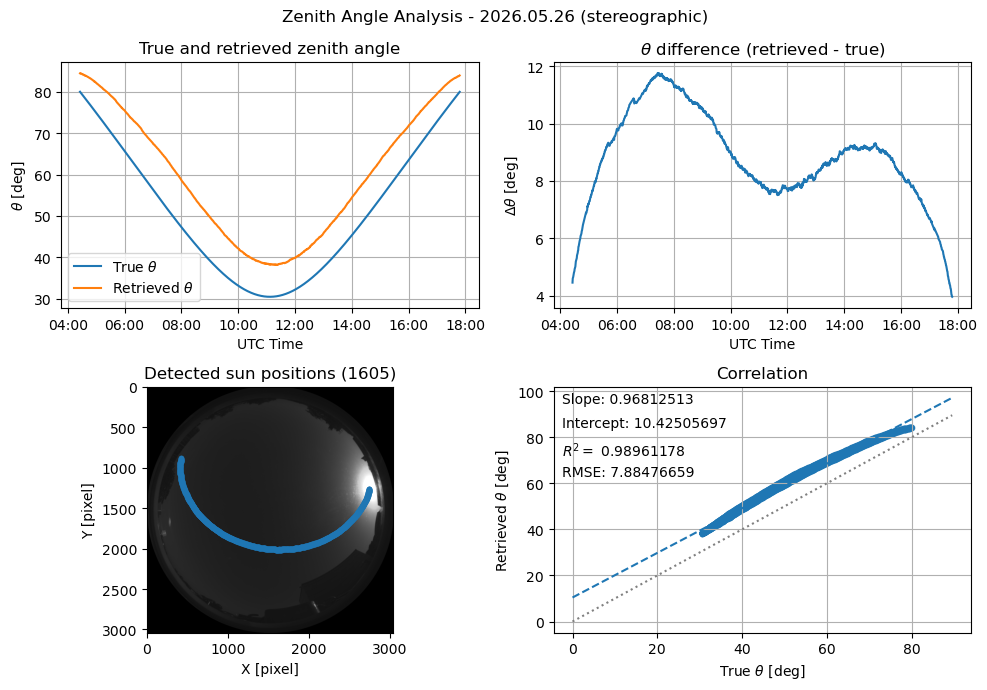

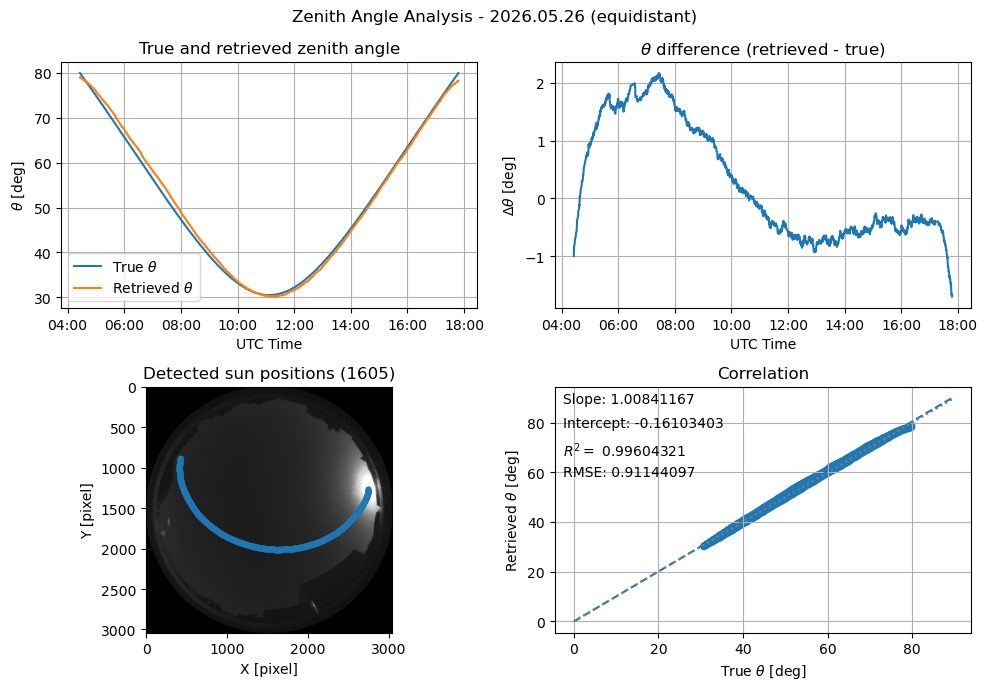

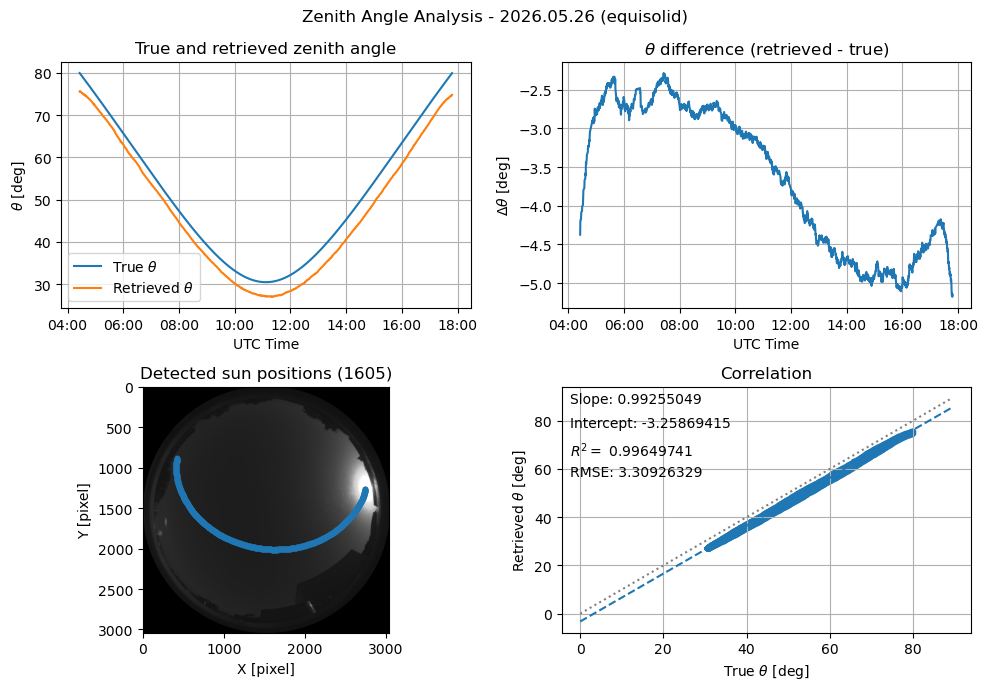

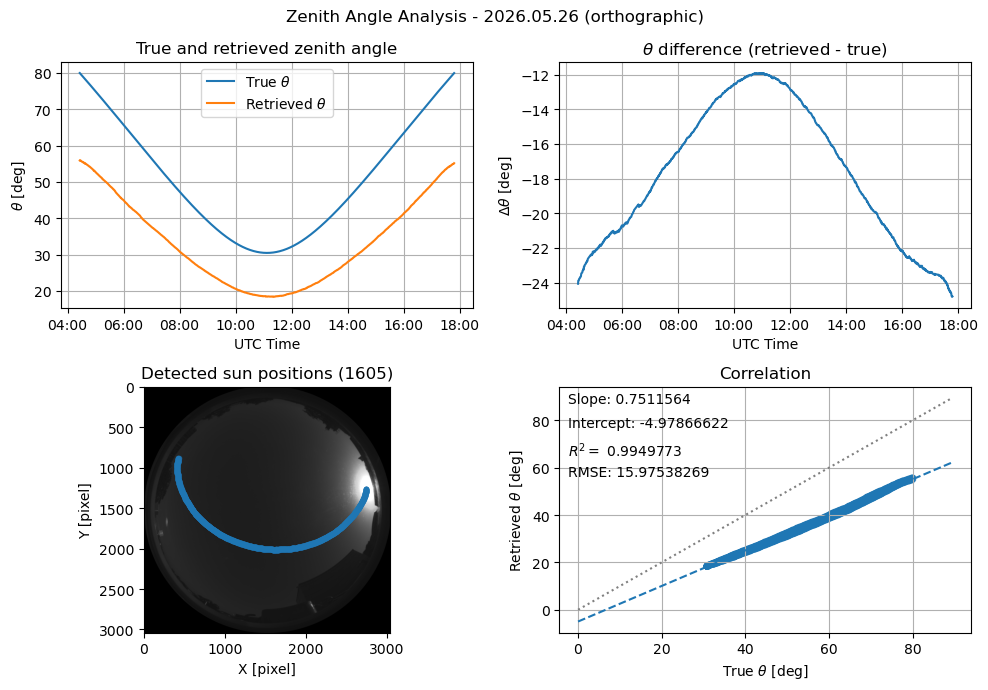

In [6]:
mapping_functions = ["rectilinear", "stereographic", "equidistant", "equisolid", "orthographic"]


def plot_theta(mapping_function):
   
    if mapping_function == "equisolid":
        fish_foclen = img_half / (2*np.sin(np.deg2rad(max_theta)/2))
        retrieved_theta_collector = np.rad2deg( 2*np.arcsin(np.array(actual_radius_collector)/(2*fish_foclen)) )
        print(" \"equisolid\" selected")
        
    elif mapping_function == "stereographic":
        fish_foclen = img_half / (2*np.tan(np.deg2rad(max_theta)/2))
        retrieved_theta_collector = np.rad2deg( 2*np.arctan(np.array(actual_radius_collector)/(2*fish_foclen)) )
        print(" \"sterographic\" selected")
        
    elif mapping_function == "equidistant":
        fish_foclen = img_half / np.deg2rad(max_theta)
        retrieved_theta_collector = np.rad2deg( np.array(actual_radius_collector)/fish_foclen )
        print(" \"equidistant\" selected")
        
    elif mapping_function == "rectilinear":
        fish_foclen = img_half / np.tan(np.deg2rad(max_theta))
        retrieved_theta_collector = np.rad2deg( np.arctan(np.array(actual_radius_collector)/fish_foclen) )
        print(" \"rectilinear\" selected")
        
    elif mapping_function == "orthographic":
        fish_foclen = img_half / np.sin(np.deg2rad(max_theta))
        retrieved_theta_collector = np.rad2deg( np.arcsin(np.array(actual_radius_collector)/fish_foclen) )
        print(" \"orthographic\" selected")


    new_true_theta = np.where(np.isnan(actual_angle_collector), np.nan, sun_theta_collector)
    
    fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10,7))
    
    fig.suptitle("Zenith Angle Analysis - {0}.{1}.{2} ({3})".format(year, month, day, mapping_function))
    
    ax[0,0].plot(timestamp_collector, new_true_theta, label=r'True $\theta$')
    ax[0,0].plot(timestamp_collector, retrieved_theta_collector, label=r'Retrieved $\theta$')
    ax[0,0].set_title("True and retrieved zenith angle")
    ax[0,0].set_xlabel("UTC Time")
    ax[0,0].xaxis.set_major_formatter(mdat.DateFormatter("%H:%M"))
    ax[0,0].set_ylabel(r'$\theta$ [deg]')
    ax[0,0].legend()
    ax[0,0].grid()
    
    ax[0,1].plot(np.array(timestamp_collector), np.array(retrieved_theta_collector)-np.array(sun_theta_collector))
    ax[0,1].set_title(r'$\theta$ difference (retrieved - true)')
    ax[0,1].set_xlabel("UTC Time")
    ax[0,1].xaxis.set_major_formatter(mdat.DateFormatter("%H:%M"))
    ax[0,1].set_ylabel(r'$\Delta\theta$ [deg]')
    ax[0,1].grid()
    
    ax[1,0].imshow(background_image, cmap="gray")
    ax[1,0].scatter(x_collector, y_collector, marker='.', alpha=0.7)
    ax[1,0].set_title("Detected sun positions ({0})".format((np.isfinite(x_collector)).sum()))
    ax[1,0].set_xlabel("X [pixel]")
    ax[1,0].set_ylabel("Y [pixel]")
    ax[1,0].set_xlim(0, img_half*2)
    ax[1,0].set_ylim(0, img_half*2)
    ax[1,0].invert_yaxis()
    
    ax[1,1].scatter(sun_theta_collector, retrieved_theta_collector, marker=".", alpha=0.7)
    ax[1,1].set_title("Correlation")
    ax[1,1].set_xlabel(r'True $\theta$ [deg]')
    ax[1,1].set_ylabel(r'Retrieved $\theta$ [deg]')
    ax[1,1].grid()
    
    lreg = stats.linregress(sun_theta_collector, retrieved_theta_collector, nan_policy = "omit")
    reg_gen_x = np.arange(0, 90, 0.5)
    reg_gen_y = lreg.slope * reg_gen_x + lreg.intercept

    rmse = np.sqrt(1/len(sun_theta_collector)  *  np.nansum((sun_theta_collector - retrieved_theta_collector)**2))
 
    ax[1,1].plot(reg_gen_x, reg_gen_y, linestyle = "--")
    ax[1,1].plot(reg_gen_x, reg_gen_x, linestyle = ":", color="gray")
    ax[1,1].text(0.02, 0.98, "Slope: {0}".format(np.round(lreg.slope, 8)), ha='left', va='top', transform=ax[1,1].transAxes)
    ax[1,1].text(0.02, 0.88, "Intercept: {0}".format(np.round(lreg.intercept, 8)), ha='left', va='top', transform=ax[1,1].transAxes)
    ax[1,1].text(0.02, 0.78, r'$R^2 =$ {0}'.format(np.round(lreg.rvalue**2, 8)), ha='left', va='top', transform=ax[1,1].transAxes)
    ax[1,1].text(0.02, 0.68, "RMSE: {0}".format(np.round(rmse, 8)), ha='left', va='top', transform=ax[1,1].transAxes)
    
    #fig.autofmt_xdate()
    fig.tight_layout()
    
    fig.savefig("{0}_theta_{1}_{2}{3}{4}.png".format(camera, mapping_function, year, month, day))

for map_func in mapping_functions:

    plot_theta(map_func)

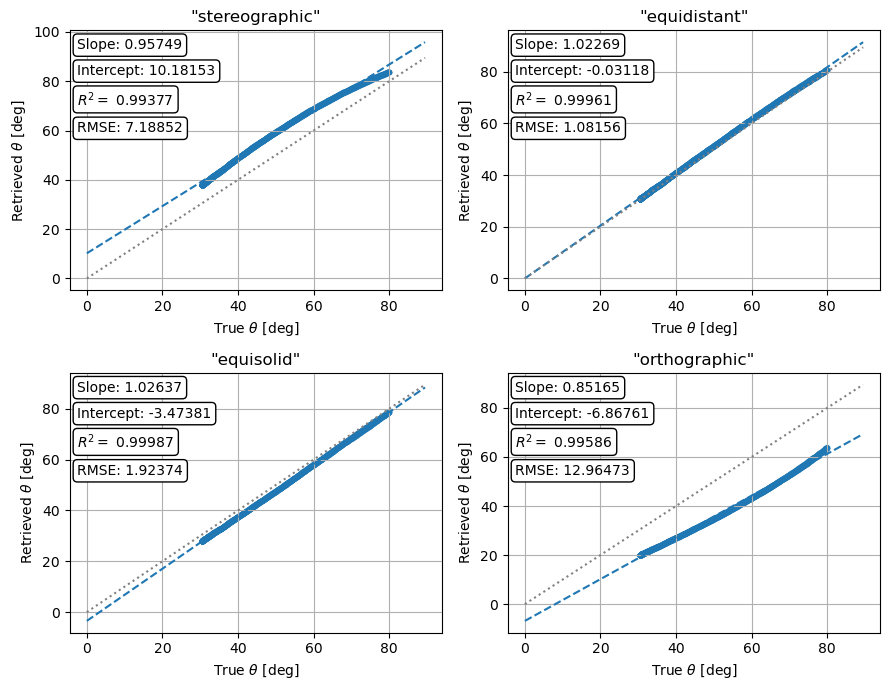

In [6]:
reg_gen_x = np.arange(0, 90, 0.5)
textbox_template = dict(boxstyle='round', facecolor='white')

fish_f_rectilinear = img_half / np.tan(np.deg2rad(max_theta))
fish_f_stereographic = img_half / (2*np.tan(np.deg2rad(max_theta)/2))
fish_f_equidistant = img_half / np.deg2rad(max_theta)
fish_f_equisolid = img_half / (2*np.sin(np.deg2rad(max_theta)/2))
fish_f_orthographic = img_half / np.sin(np.deg2rad(max_theta))

theta_retrieve_rectilinear = np.rad2deg( np.arctan(np.array(actual_radius_collector)/fish_f_rectilinear) )
theta_retrieve_stereographic = np.rad2deg( 2*np.arctan(np.array(actual_radius_collector)/(2*fish_f_stereographic)) )
theta_retrieve_equidistant = np.rad2deg( np.array(actual_radius_collector)/fish_f_equidistant )
theta_retrieve_equisolid = np.rad2deg( 2*np.arcsin(np.array(actual_radius_collector)/(2*fish_f_equisolid)) )
theta_retrieve_orthographic = np.rad2deg( np.arcsin(np.array(actual_radius_collector)/fish_f_orthographic) )

lreg_rectilinear = stats.linregress(sun_theta_collector, theta_retrieve_rectilinear, nan_policy = "omit")
lreg_stereographic = stats.linregress(sun_theta_collector, theta_retrieve_stereographic, nan_policy = "omit")
lreg_equidistant = stats.linregress(sun_theta_collector, theta_retrieve_equidistant, nan_policy = "omit")
lreg_equisolid = stats.linregress(sun_theta_collector, theta_retrieve_equisolid, nan_policy = "omit")
lreg_orthographic = stats.linregress(sun_theta_collector, theta_retrieve_orthographic, nan_policy = "omit")

reg_gen_y_rectilinear = lreg_rectilinear.slope * reg_gen_x + lreg_rectilinear.intercept
reg_gen_y_stereographic = lreg_stereographic.slope * reg_gen_x + lreg_stereographic.intercept
reg_gen_y_equidistant = lreg_equidistant.slope * reg_gen_x + lreg_equidistant.intercept
reg_gen_y_equisolid  = lreg_equisolid.slope * reg_gen_x + lreg_equisolid.intercept
reg_gen_y_orthographic = lreg_orthographic.slope * reg_gen_x + lreg_orthographic.intercept

rmse_rectilinear = np.sqrt(1/len(sun_theta_collector)  *  np.nansum((sun_theta_collector - theta_retrieve_rectilinear)**2))
rmse_stereographic = np.sqrt(1/len(sun_theta_collector)  *  np.nansum((sun_theta_collector - theta_retrieve_stereographic)**2))
rmse_equidistant = np.sqrt(1/len(sun_theta_collector)  *  np.nansum((sun_theta_collector - theta_retrieve_equidistant)**2))
rmse_equisolid = np.sqrt(1/len(sun_theta_collector)  *  np.nansum((sun_theta_collector - theta_retrieve_equisolid)**2))
rmse_orthographic = np.sqrt(1/len(sun_theta_collector)  *  np.nansum((sun_theta_collector - theta_retrieve_orthographic)**2))



fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(9,7))



# ax[0,0] --> stereographic
ax[0,0].scatter(sun_theta_collector, theta_retrieve_stereographic, marker=".", alpha=0.7)

ax[0,0].plot(reg_gen_x, reg_gen_y_stereographic, linestyle = "--")
ax[0,0].plot(reg_gen_x, reg_gen_x, linestyle = ":", color="gray")

ax[0,0].grid()

ax[0,0].text(0.02, 0.97, "Slope: {0}".format(np.round(lreg_stereographic.slope, 5)), ha='left', va='top', bbox=textbox_template, transform=ax[0,0].transAxes)
ax[0,0].text(0.02, 0.87, "Intercept: {0}".format(np.round(lreg_stereographic.intercept, 5)), ha='left', va='top', bbox=textbox_template, transform=ax[0,0].transAxes)
ax[0,0].text(0.02, 0.77, r'$R^2 =$ {0}'.format(np.round(lreg_stereographic.rvalue**2, 5)), ha='left', va='top', bbox=textbox_template, transform=ax[0,0].transAxes)
ax[0,0].text(0.02, 0.65, "RMSE: {0}".format(np.round(rmse_stereographic, 5)), ha='left', va='top', bbox=textbox_template, transform=ax[0,0].transAxes)

ax[0,0].set_title("\"stereographic\"")
ax[0,0].set_xlabel(r'True $\theta$ [deg]')
ax[0,0].set_ylabel(r'Retrieved $\theta$ [deg]')


# ax[0,1] --> equidistant
ax[0,1].scatter(sun_theta_collector, theta_retrieve_equidistant, marker=".", alpha=0.7)

ax[0,1].plot(reg_gen_x, reg_gen_y_equidistant, linestyle = "--")
ax[0,1].plot(reg_gen_x, reg_gen_x, linestyle = ":", color="gray")

ax[0,1].grid()

ax[0,1].text(0.02, 0.97, "Slope: {0}".format(np.round(lreg_equidistant.slope, 5)), ha='left', va='top', bbox=textbox_template, transform=ax[0,1].transAxes)
ax[0,1].text(0.02, 0.87, "Intercept: {0}".format(np.round(lreg_equidistant.intercept, 5)), ha='left', va='top', bbox=textbox_template, transform=ax[0,1].transAxes)
ax[0,1].text(0.02, 0.77, r'$R^2 =$ {0}'.format(np.round(lreg_equidistant.rvalue**2, 5)), ha='left', va='top', bbox=textbox_template, transform=ax[0,1].transAxes)
ax[0,1].text(0.02, 0.65, "RMSE: {0}".format(np.round(rmse_equidistant, 5)), ha='left', va='top', bbox=textbox_template, transform=ax[0,1].transAxes)

ax[0,1].set_title("\"equidistant\"")
ax[0,1].set_xlabel(r'True $\theta$ [deg]')
ax[0,1].set_ylabel(r'Retrieved $\theta$ [deg]')


# ax[1,0] --> equisolid
ax[1,0].scatter(sun_theta_collector, theta_retrieve_equisolid, marker=".", alpha=0.7)

ax[1,0].plot(reg_gen_x, reg_gen_y_equisolid, linestyle = "--")
ax[1,0].plot(reg_gen_x, reg_gen_x, linestyle = ":", color="gray")

ax[1,0].grid()

ax[1,0].text(0.02, 0.97, "Slope: {0}".format(np.round(lreg_equisolid.slope, 5)), ha='left', va='top', bbox=textbox_template, transform=ax[1,0].transAxes)
ax[1,0].text(0.02, 0.87, "Intercept: {0}".format(np.round(lreg_equisolid.intercept, 5)), ha='left', va='top', bbox=textbox_template, transform=ax[1,0].transAxes)
ax[1,0].text(0.02, 0.77, r'$R^2 =$ {0}'.format(np.round(lreg_equisolid.rvalue**2, 5)), ha='left', va='top', bbox=textbox_template, transform=ax[1,0].transAxes)
ax[1,0].text(0.02, 0.65, "RMSE: {0}".format(np.round(rmse_equisolid, 5)), ha='left', va='top', bbox=textbox_template, transform=ax[1,0].transAxes)

ax[1,0].set_title("\"equisolid\"")
ax[1,0].set_xlabel(r'True $\theta$ [deg]')
ax[1,0].set_ylabel(r'Retrieved $\theta$ [deg]')


# ax[1,1] --> orthographic
ax[1,1].scatter(sun_theta_collector, theta_retrieve_orthographic, marker=".", alpha=0.7)

ax[1,1].plot(reg_gen_x, reg_gen_y_orthographic, linestyle = "--")
ax[1,1].plot(reg_gen_x, reg_gen_x, linestyle = ":", color="gray")

ax[1,1].grid()

ax[1,1].text(0.02, 0.97, "Slope: {0}".format(np.round(lreg_orthographic.slope, 5)), ha='left', va='top', bbox=textbox_template, transform=ax[1,1].transAxes)
ax[1,1].text(0.02, 0.87, "Intercept: {0}".format(np.round(lreg_orthographic.intercept, 5)), ha='left', va='top', bbox=textbox_template, transform=ax[1,1].transAxes)
ax[1,1].text(0.02, 0.77, r'$R^2 =$ {0}'.format(np.round(lreg_orthographic.rvalue**2, 5)), ha='left', va='top', bbox=textbox_template, transform=ax[1,1].transAxes)
ax[1,1].text(0.02, 0.65, "RMSE: {0}".format(np.round(rmse_orthographic, 5)), ha='left', va='top', bbox=textbox_template, transform=ax[1,1].transAxes)

ax[1,1].set_title("\"orthographic\"")
ax[1,1].set_xlabel(r'True $\theta$ [deg]')
ax[1,1].set_ylabel(r'Retrieved $\theta$ [deg]')

fig.tight_layout()

fig.savefig(camera + "_mapping_functions_correlations.png")

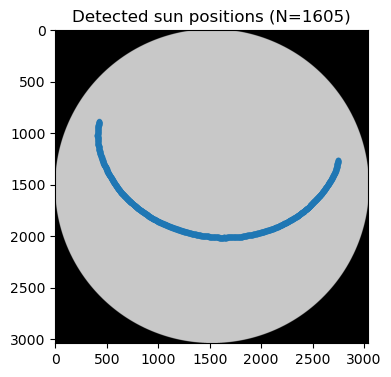

In [8]:
circle_custom = np.full((3040,3040,3), 0, dtype="int16")
circle_custom = cv2.circle(circle_custom, center=(1520,1520), radius=1520, color=(200,200,200), thickness=-1)

sun_phi_collector = np.array(sun_phi_collector)

new_true_phi = np.where(np.isnan(actual_angle_collector), np.nan, sun_phi_collector)

fig1 = plt.figure(figsize=(4,4))
plt.imshow(circle_custom, cmap="gray")
plt.scatter(x_collector, y_collector, marker='.', alpha=0.7)
plt.title("Detected sun positions (N={0})".format((np.isfinite(x_collector)).sum()))
plt.tight_layout()

fig2 = plt.figure(figsize=(4,4))
plt.plot(timestamp_collector, new_true_phi, label=r'True')
plt.plot(timestamp_collector, actual_angle_collector, label=r'Retrieved')
plt.title("True and retrieved azimuth angle")
plt.xlabel("UTC Time [hr]")
plt.gca().xaxis.set_major_formatter(mdat.DateFormatter("%H"))
plt.ylabel(r'$\varphi$ [deg]')
plt.legend()
plt.grid()
plt.tight_layout()


lreg = stats.linregress(sun_phi_collector, actual_angle_collector, nan_policy = "omit")
reg_gen_x = np.arange(0, 360, 1)
reg_gen_y = lreg.slope * reg_gen_x + lreg.intercept
rmse_phi = np.sqrt(1/len(sun_phi_collector)  *  np.nansum((sun_phi_collector - actual_angle_collector)**2))

fig3 = plt.figure(figsize=(4,4))
plt.scatter(sun_phi_collector, actual_angle_collector, marker=".", alpha=0.7)
plt.title("Correlation")
plt.xlabel(r'True $\varphi$ [deg]')
plt.ylabel(r'Retrieved $\varphi$ [deg]')
plt.grid()
plt.plot(reg_gen_x, reg_gen_y, linestyle = "--")
plt.plot(reg_gen_x, reg_gen_x, linestyle = ":", color="gray")
plt.text(0.02, 0.97, "Slope: {0}".format(np.round(lreg.slope, 5)), ha='left', va='top', bbox=textbox_template, transform=plt.gca().transAxes)
plt.text(0.02, 0.87, "Intercept: {0}".format(np.round(lreg.intercept, 5)), ha='left', va='top', bbox=textbox_template, transform=plt.gca().transAxes)
plt.text(0.02, 0.77, r'$R^2 =$ {0}'.format(np.round(lreg.rvalue**2, 5)), ha='left', va='top', bbox=textbox_template, transform=plt.gca().transAxes)
plt.text(0.02, 0.65, "RMSE: {0}".format(np.round(rmse_phi, 5)), ha='left', va='top', bbox=textbox_template, transform=plt.gca().transAxes)
plt.tight_layout()

fig1.savefig("sunfit_pos.png")
fig2.savefig("sunfit_phi_comp.png")
fig3.savefig("sunfit_phi_corr.png")

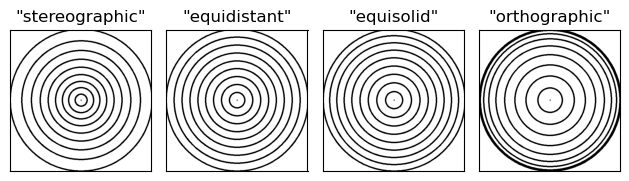

In [9]:
circles = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]
theta_rad = np.deg2rad(circles)

f_rectilinear = 250 / np.tan(np.deg2rad(90))
f_stereographic = 250 / (2*np.tan(np.deg2rad(90)/2))
f_equidistant = 250 / np.deg2rad(90)
f_equisolid = 250 / (2*np.sin(np.deg2rad(90)/2))
f_orthographic = 250 / np.sin(np.deg2rad(90))

r_rectilinear = f_rectilinear * np.tan(theta_rad)
r_stereographic = 2*f_stereographic * np.tan(theta_rad/2)
r_equidistant = f_equidistant * theta_rad
r_equisolid = 2*f_equisolid * np.sin(theta_rad/2)
r_orthographic = f_orthographic * np.sin(theta_rad)

images = np.full((4, 500, 500, 3), 255, dtype="uint8")

fig, ax = plt.subplots(nrows=1, ncols=4)

for i in range(len(circles)):

    images[0,:,:,:] = cv2.circle(images[0,:,:,:], center=(250,250), radius=int(r_stereographic[i]), color=(0,0,0), thickness=3)
    images[1,:,:,:] = cv2.circle(images[1,:,:,:], center=(250,250), radius=int(r_equidistant[i]), color=(0,0,0), thickness=3)
    images[2,:,:,:] = cv2.circle(images[2,:,:,:], center=(250,250), radius=int(r_equisolid[i]), color=(0,0,0), thickness=3)
    images[3,:,:,:] = cv2.circle(images[3,:,:,:], center=(250,250), radius=int(r_orthographic[i]), color=(0,0,0), thickness=3)

ax[0].imshow(images[0,:,:,:])
ax[1].imshow(images[1,:,:,:])
ax[2].imshow(images[2,:,:,:])
ax[3].imshow(images[3,:,:,:])

ax[0].set_title("\"stereographic\"")
ax[1].set_title("\"equidistant\"")
ax[2].set_title("\"equisolid\"")
ax[3].set_title("\"orthographic\"")

ax[0].set_xticks([])
ax[1].set_xticks([])
ax[2].set_xticks([])
ax[3].set_xticks([])

ax[0].set_yticks([])
ax[1].set_yticks([])
ax[2].set_yticks([])
ax[3].set_yticks([])

fig.tight_layout()

plt.savefig("mapping_functions.png")

 "equidistant" selected


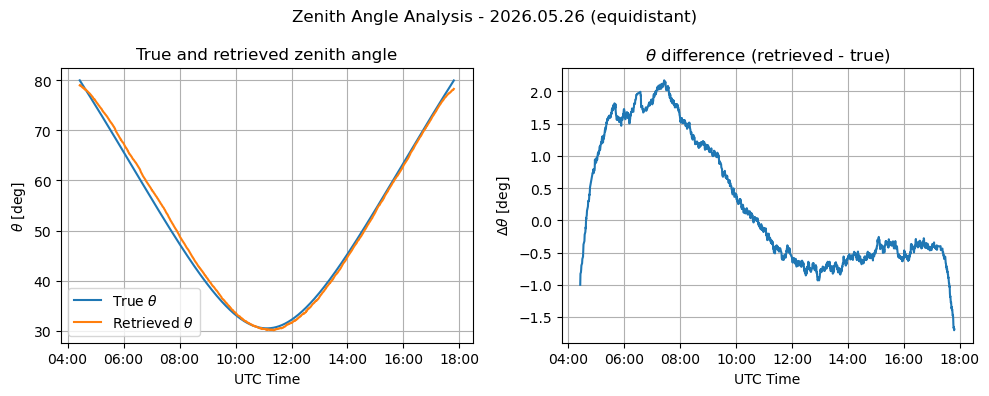

In [11]:

fish_foclen = img_half / np.deg2rad(max_theta)
retrieved_theta_collector = np.rad2deg( np.array(actual_radius_collector)/fish_foclen )
print(" \"equidistant\" selected")

new_true_theta = np.where(np.isnan(actual_angle_collector), np.nan, sun_theta_collector)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,4), tight_layout=True)

fig.suptitle("Zenith Angle Analysis - {0}.{1}.{2} (equidistant)".format(year, month, day))

ax[0].plot(timestamp_collector, new_true_theta, label=r'True $\theta$')
ax[0].plot(timestamp_collector, retrieved_theta_collector, label=r'Retrieved $\theta$')
ax[0].set_title("True and retrieved zenith angle")
ax[0].set_xlabel("UTC Time")
ax[0].xaxis.set_major_formatter(mdat.DateFormatter("%H:%M"))
ax[0].set_ylabel(r'$\theta$ [deg]')
ax[0].legend()
ax[0].grid()

ax[1].plot(np.array(timestamp_collector), np.array(retrieved_theta_collector)-np.array(sun_theta_collector))
ax[1].set_title(r'$\theta$ difference (retrieved - true)')
ax[1].set_xlabel("UTC Time")
ax[1].xaxis.set_major_formatter(mdat.DateFormatter("%H:%M"))
ax[1].set_ylabel(r'$\Delta\theta$ [deg]')
ax[1].grid()

fig.savefig("sunfit_theta_comp.png")